In [1]:
# https://pytorch.org/tutorials/beginner/basics/data_tutorial.html

In [2]:
import torch
import torch.nn
# The Dataset class is an abstract class representing a dataset. Your custom dataset should inherit Dataset and override the following methods:
from torchvision import datasets
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import datasets
# The ToTensor function from torchvision.transforms is used to convert a PIL Image or a NumPy ndarray into a PyTorch tensor.
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Useful functions (read the documents to know their meaning!)

In [4]:
# https://pytorch.org/docs/stable/generated/torch.randint.html
torch.randint(10, size=(1,))

tensor([5])

In [5]:
# https://pytorch.org/docs/main/generated/torch.randn.html
torch.randn(1, 5)

tensor([[-2.2527, -0.1517, -1.2205,  0.9584,  1.0539]])

In [6]:
# https://pytorch.org/docs/main/generated/torch.squeeze.html
torch.randn(1,5).squeeze() # notice the difference with the previous line

tensor([-1.2776, -1.2343,  0.1210,  0.0240, -0.1418])

In [7]:
# Let's go back to the tutorial

In [8]:
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

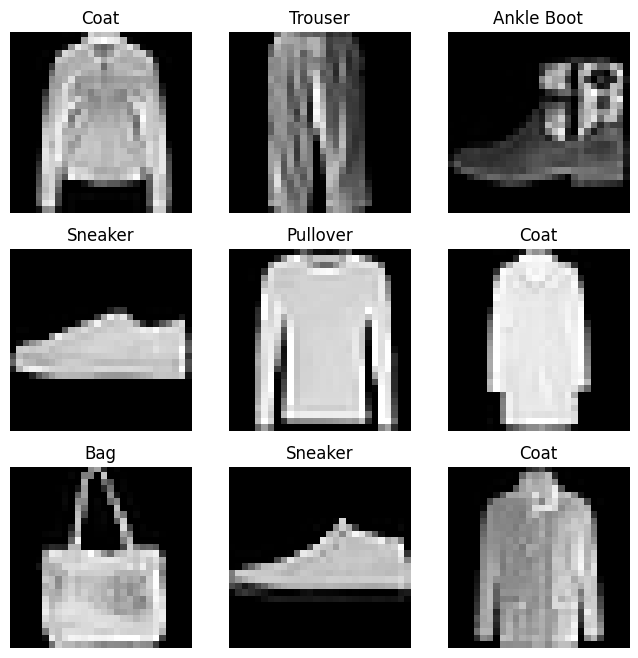

In [9]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
# You better learn how to use matplotlib though using it itself could be a big problem 
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [10]:
# https://pytorch.org/tutorials/beginner/basics/data_tutorial.html#preparing-your-data-for-training-with-dataloaders
# The Dataset retrieves our dataset’s features and labels one sample at a time. 
# While training a model, we typically want to pass samples in “minibatches”, reshuffle the data at every epoch to reduce model overfitting, 
# and use Python’s multiprocessing to speed up data retrieval.
# DataLoader is an iterable that abstracts this complexity for us in an easy API.

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


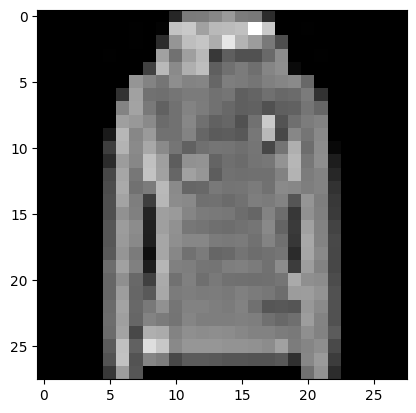

Label: 2


In [11]:
# Display image and label.
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")  # batch x channel x width x height 
print(f"Labels batch shape: {train_labels.size()}") # 'f' means it is a formatted string
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")